In [370]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [371]:
df=pd.read_csv(r"C:\Users\Sarvesh\Downloads\adult Income - adult Income.csv.csv")

In [372]:
df.shape

(32561, 15)

In [373]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [375]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [376]:
categorical_columns = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
# Replace '?' with the mode for each column
for column in categorical_columns:
    if column in df.columns:
        mode_value = df[column].mode()[0] 
        df[column].replace('?', mode_value, inplace=True)

C:\Users\Sarvesh\AppData\Local\Temp\ipykernel_20380\2153669988.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].replace('?', mode_value, inplace=True)


In [377]:
numerical_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
for column in numerical_cols:
    df[column].fillna(df[column].mean(), inplace=True)

C:\Users\Sarvesh\AppData\Local\Temp\ipykernel_20380\1883151276.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


In [378]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [379]:
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
print(df['income'].unique())

[0 1]


In [380]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,0
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0


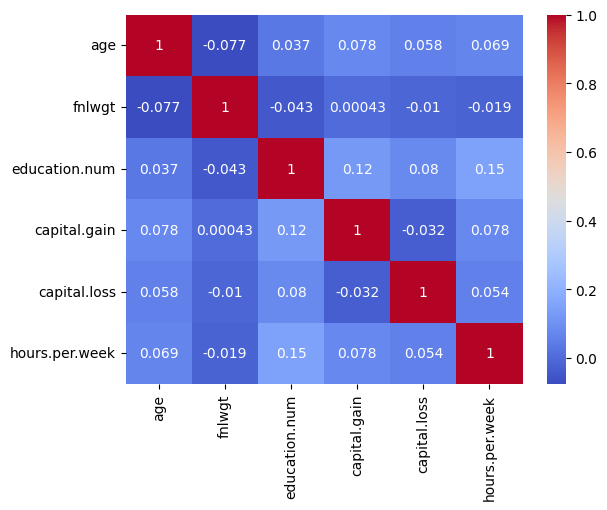

In [381]:
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [382]:
df.drop(columns=['fnlwgt'], inplace=True)

In [383]:
df.describe()

,age,education.num,capital.gain,capital.loss,hours.per.week,income
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,10.080679,1077.648844,87.303830,40.437456,0.240810
std,13.640433,2.572720,7385.292085,402.960219,12.347429,0.427581
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


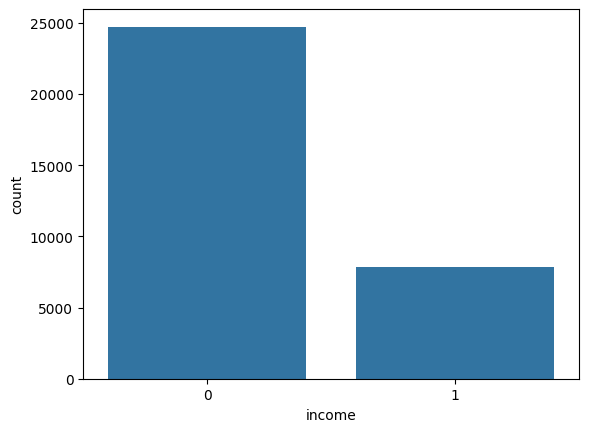

In [384]:
sns.countplot(data=df, x='income')
plt.show()

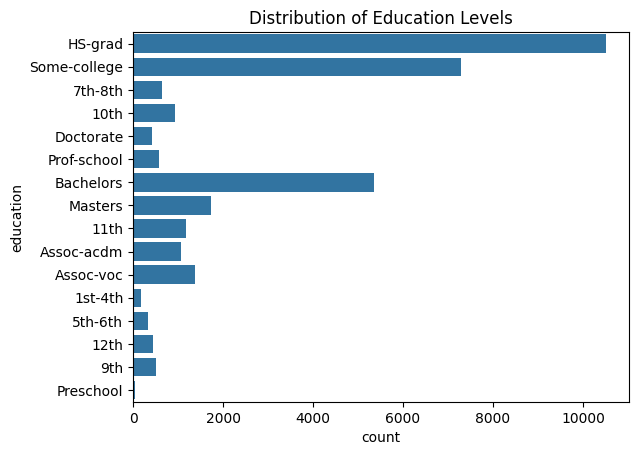

In [385]:
sns.countplot(data=df, y='education')
plt.title('Distribution of Education Levels')
plt.show()

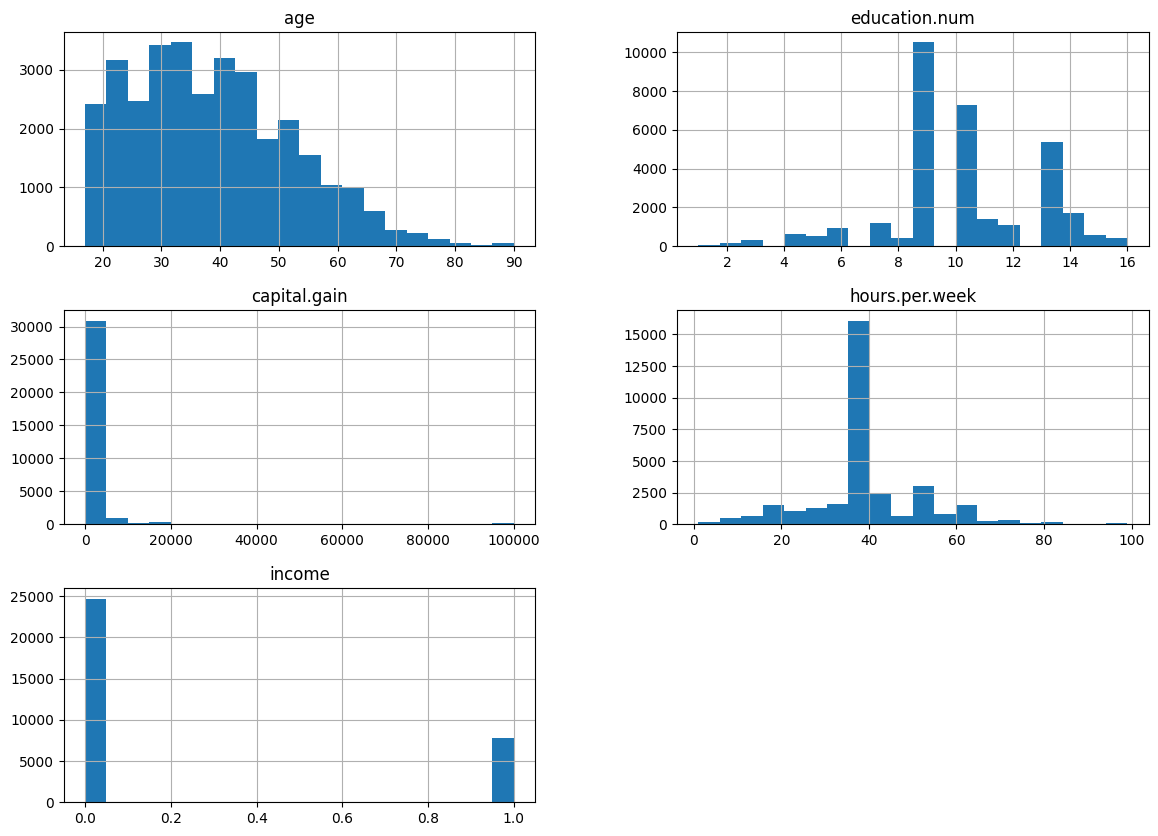

In [386]:
df[['age', 'education.num', 'capital.gain', 'hours.per.week','income']].hist(bins=20, figsize=(14, 10))                                                              
plt.show()


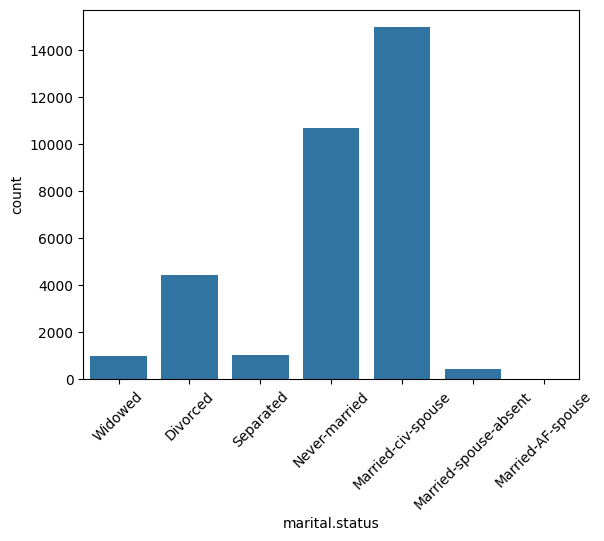

In [387]:
sns.countplot(data=df, x='marital.status')
plt.xticks(rotation=45)
plt.show()

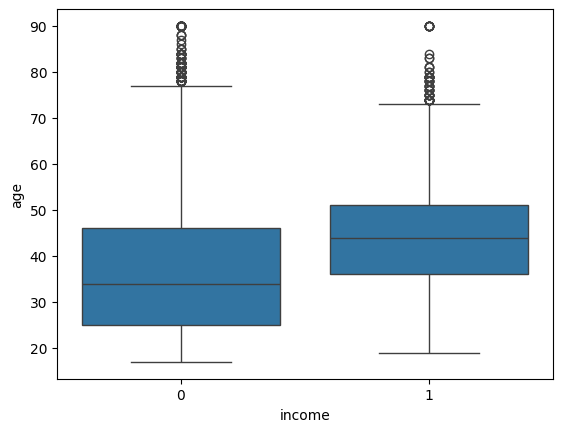

In [388]:
sns.boxplot(data=df, x='income', y='age')
plt.show()


In [389]:
Q1 = df['capital.gain'].quantile(0.25)
Q3 = df['capital.gain'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['capital.gain'] < lower_bound) | (df['capital.gain'] > upper_bound)]
print(outliers)

      age     workclass     education  education.num      marital.status  \
1519   54  Self-emp-inc   Prof-school             15  Married-civ-spouse   
1520   52       Private       HS-grad              9  Married-civ-spouse   
1521   53  Self-emp-inc       HS-grad              9  Married-civ-spouse   
1522   52       Private     Bachelors             13  Married-civ-spouse   
1523   46       Private   Prof-school             15  Married-civ-spouse   
...   ...           ...           ...            ...                 ...   
4226   20       Private           9th              5       Never-married   
4227   39       Private  Some-college             10            Divorced   
4228   33       Private           9th              5            Divorced   
4229   38       Private          10th              6             Widowed   
4230   25       Private       HS-grad              9       Never-married   

            occupation relationship                race     sex  capital.gain  \
1519  

In [390]:
cross_tab = pd.crosstab(df['workclass'], df['income'])
print(cross_tab)

income                0     1
workclass                    
Federal-gov         589   371
Local-gov          1476   617
Never-worked          7     0
Private           19378  5154
Self-emp-inc        494   622
Self-emp-not-inc   1817   724
State-gov           945   353
Without-pay          14     0


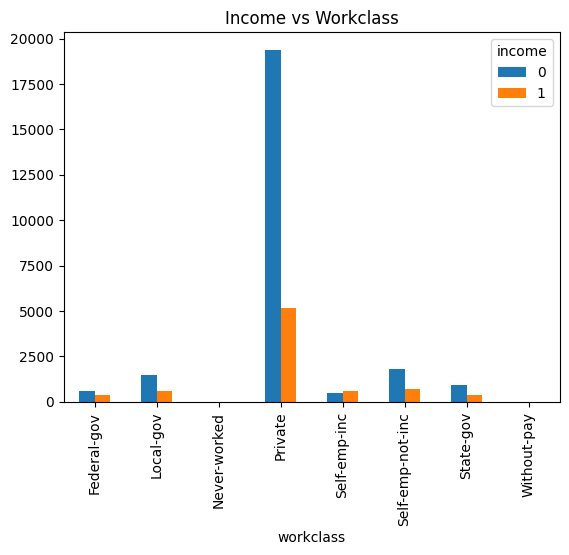

In [391]:
cross_tab.plot(kind='bar')
plt.title('Income vs Workclass')
plt.show()

In [392]:
df.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,0
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
2,66,Private,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,0
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0


In [393]:
#splitting tha dataset into dependent and independent features
X = df.drop(columns=['income'])
Y = df['income']

In [394]:
X

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,Private,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States
2,66,Private,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States
32557,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
32558,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
32559,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States


In [395]:
Y

0        0
1        0
2        0
3        0
4        0
        ..
32556    0
32557    0
32558    1
32559    0
32560    0
Name: income, Length: 32561, dtype: int64

In [396]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30)

In [397]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
X_train['workclass'] = label_encoder.fit_transform(X_train['workclass'])
X_train['education'] = label_encoder.fit_transform(X_train['education'])
X_train['marital.status'] = label_encoder.fit_transform(X_train['marital.status'])
X_train['occupation'] = label_encoder.fit_transform(X_train['occupation'])
X_train['relationship'] = label_encoder.fit_transform(X_train['relationship'])
X_train['race'] = label_encoder.fit_transform(X_train['race'])
X_train['sex'] = label_encoder.fit_transform(X_train['sex'])
X_train['native.country'] = label_encoder.fit_transform(X_train['native.country'])

In [398]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
#as it basically does the classification

In [399]:
#always write parameters in dictionary
from sklearn.model_selection import GridSearchCV
classifier = LogisticRegression(solver='lbfgs', penalty='l2')
# Define the parameter grid
parameter = {'C': [0.1, 1, 10]}  # Regularization parameter
# Apply GridSearchCV
#PARAMETERES:
#estimator:konsa model=classifier
classifier_regressor = GridSearchCV(classifier, param_grid=parameter, scoring='accuracy', cv=5)

In [400]:
classifier_regressor.fit(X_train,y_train)

C:\Users\Sarvesh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Sarvesh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1, 10]}, scoring='accuracy')

In [401]:
print("Best Parameters:", classifier_regressor.best_params_)

Best Parameters: {'C': 1}


In [402]:
print("Best Score:", classifier_regressor.best_score_)

Best Score: 0.8059405805276842


In [403]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Step 1: One-hot encode categorical columns for both training and test data
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
# Step 2: Ensure both training and test data have the same columns (if necessary)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)
# Step 3: Apply scaling to numerical columns (if needed)
numerical_columns = ['age','education.num', 'hours.per.week']  # adjust if necessary
scaler = StandardScaler()
# Apply scaling to the numerical columns in both train and test data
X_train_encoded[numerical_columns] = scaler.fit_transform(X_train_encoded[numerical_columns])
X_test_encoded[numerical_columns] = scaler.transform(X_test_encoded[numerical_columns])
# Step 4: Fit the classifier using GridSearchCV
classifier_regressor.fit(X_train_encoded, y_train)
# Step 5: Make predictions on X_test
y_pred = classifier_regressor.predict(X_test_encoded)



C:\Users\Sarvesh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Sarvesh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

In [404]:
#accuracy score
from sklearn.metrics import accuracy_score,classification_report

In [405]:
score=accuracy_score(y_pred,y_test)
print(score)

0.6702835500051182
